## From the variational problem to the weak and the strong form

### The principle of minimum potential energy

In lecture 1 the finite element method was derived from the operator equation $Au = f$: multiply by a test function,
integrate, integrate by parts $s$ times. Mechanics offers a second, physically motivated starting point. A body in
equilibrium takes the state $u$ that **minimizes its total potential energy**

$$\Pi(u) = U(u) - W(u),$$

the stored (strain) energy $U$ minus the work $W$ of the applied loads, among all *admissible* states, i.e. all $u$
that satisfy the essential (Dirichlet) boundary conditions.

For an operator $A$ that is symmetric and positive in the sense of lecture 1, the functional has the form

$$\Pi(u) = \tfrac12\, [u, u] - (f, u), \qquad [u, v] := (Au, v),$$

with the **energy inner product** $[u, v]$. After $s$ integrations by parts it contains only derivatives of order $s$
of $u$ and $v$ (examples below), which is what makes it the natural object for finite elements.
The scriptum `FEM_Skriptum_v21.pdf`, pages 59 to 62, treats the same topic for the bar under its own weight.

### Why the minimizer solves $Au = f$

Let $u$ be the solution of $Au = f$ and $v$ any admissible function. Using $(f, v) = (Au, v) = [u, v]$ and the
symmetry $[u, v] = [v, u]$,

$$\Pi(v) = \tfrac12\, [v, v] - [u, v] = \tfrac12\, [v - u, v - u] - \tfrac12\, [u, u] .$$

Because the operator is positive, $[v - u, v - u] > 0$ for $v \neq u$, so $\Pi$ is smallest exactly for $v = u$.
The minimum value is $\Pi(u) = -\tfrac12 [u, u] = -U(u)$: at equilibrium the work of the loads, $(f, u) = [u, u]$,
is twice the stored energy. (We will check this number in FEniCS below.)

### Directional derivative: the weak form

A minimum of $\Pi$ is characterized as in calculus: the derivative vanishes in every direction. For a direction $v$
with $v = 0$ on the Dirichlet boundary (so that $u + \varepsilon v$ is still admissible) the **directional derivative** is

$$\delta\Pi(u; v) := \frac{d}{d\varepsilon}\, \Pi(u + \varepsilon v)\,\Big|_{\varepsilon = 0} .$$

For $\Pi(u) = \tfrac12 [u, u] - (f, u)$ one finds
$\Pi(u + \varepsilon v) = \Pi(u) + \varepsilon\, \big([u, v] - (f, v)\big) + \tfrac12 \varepsilon^2\, [v, v]$, hence

$$\delta\Pi(u; v) = [u, v] - (f, v) = 0 \qquad \text{for all admissible } v .$$

This is precisely the **variational formulation (weak form)** of lecture 1: the direction $v$ is the test function,
and the Galerkin method takes the basis functions of the finite element space as directions.

### Euler–Lagrange equation: the strong form

Integrating by parts in the weak form moves the $s$ derivatives from $v$ back onto $u$. What remains is
$\int_\Omega (Au - f)\, v \; dV + \text{boundary terms} = 0$ for all $v$, and since $v$ is arbitrary, $Au = f$ must hold
pointwise: the **strong form**, also called the **Euler–Lagrange equation** of the functional. For a functional
$\Pi(u) = \int_0^L \mathcal{F}(x, u, u', u'') \, dx$ in one dimension it reads

$$\frac{\partial \mathcal{F}}{\partial u} - \frac{d}{dx}\frac{\partial \mathcal{F}}{\partial u'}
  + \frac{d^2}{dx^2}\frac{\partial \mathcal{F}}{\partial u''} = 0 .$$

The three formulations are equivalent:

$$\min_u \Pi(u) \quad\overset{\delta\Pi = 0}{\longrightarrow}\quad [u, v] = (f, v) \;\; \text{for all } v
  \quad\overset{\text{integrate by parts}}{\longrightarrow}\quad Au = f .$$

In the reverse direction the weak form follows from the strong one as in lecture 1, and for a symmetric positive
operator the weak form is the derivative of $\tfrac12 [u, u] - (f, u)$, so the functional can be written down directly.

### Boundary terms: the functional contains the Neumann conditions

Loads acting on the boundary do work too, and this work is part of $\Pi$. For a traction $T$ (force per area)
prescribed on a part $\Gamma$ of the boundary the functional gets the term $-\int_\Gamma T \cdot u \; ds$; for the
heat conduction problem of lecture 1 the corresponding term is $+\int_\Gamma g\, u \; ds$ with the outward flux $g$
(exercise 1). The directional derivative then reproduces the boundary integral of the weak form of lecture 1, and
integrating by parts once more produces, next to $Au = f$, the boundary condition on $\Gamma$ itself, as the
condition for the boundary terms to vanish: the **natural (Neumann) condition**. It need not be imposed, it follows
from the minimization. The **essential (Dirichlet) conditions**, in contrast, restrict the set of admissible
functions and have to be built into the function space, as with `DirichletBC` in FEniCS.

The variational formulation is thus the most complete picture: the functional contains the differential equation
*and* the Neumann conditions, and only the Dirichlet conditions are added separately. This is exactly what makes it
so valuable for the finite element method.

### Example: the biharmonic equation (beam bending)

A beam of wood or metal of length $L$ and bending stiffness $EI$, with deflection $u(x)$, under a distributed load
$q(x)$ (force per length), clamped at $x = 0$ and loaded at the free end $x = L$ by a force $P$ and a moment $M$:

$$\Pi(u) = \underbrace{\int_0^L \tfrac12\, EI\, (u'')^2 \, dx}_{\text{strain energy } U}
  \;-\; \underbrace{\int_0^L q\, u \, dx \;+\; P\, u(L) \;+\; M\, u'(L)}_{\text{work of the loads } W} ,
  \qquad u(0) = 0, \quad u'(0) = 0 .$$

- **Directional derivative** (for all $v$ with $v(0) = v'(0) = 0$):
  $$\delta\Pi(u; v) = \int_0^L EI\, u''\, v'' \, dx - \int_0^L q\, v \, dx - P\, v(L) - M\, v'(L) = 0 .$$
  This is the weak form, with the energy inner product $[u, v] = \int_0^L EI\, u''\, v'' \, dx$ ($s = 2$).
- **Integration by parts** (twice, as in exercise 2 of lecture 1):
  $$\int_0^L EI\, u''\, v'' \, dx = \int_0^L EI\, u''''\, v \, dx + EI\, u''(L)\, v'(L) - EI\, u'''(L)\, v(L) ,$$
  hence
  $$\delta\Pi(u; v) = \int_0^L \big(EI\, u'''' - q\big)\, v \, dx + \big(EI\, u''(L) - M\big)\, v'(L)
    + \big(-EI\, u'''(L) - P\big)\, v(L) = 0 .$$
- **Strong form:** $EI\, u'''' = q$ in $(0, L)$, the biharmonic equation (the same follows from the Euler–Lagrange
  equation with $\mathcal{F} = \tfrac12 EI\, (u'')^2 - q\, u$), together with the **natural boundary conditions**
  $EI\, u''(L) = M$ (bending moment) and $-EI\, u'''(L) = P$ (shear force) at the free end.
  The clamping $u(0) = u'(0) = 0$ is essential.

Compare with exercise 2 of lecture 1: the load vector there, $F_3 = -u'''(1)$ and $F_4 = u''(1)$, is nothing but the
boundary work $P\, u(1) + M\, u'(1)$ of the functional.

### From the functional to a system of equations

Inserting the finite element approximation $u_h = \sum_i U_i\, \varphi_i$ into the functional turns the minimization
over functions into the minimization of an ordinary function of the $N$ unknowns $U_i$ (scriptum, section 7.2.3;
the Ritz method):

$$\Pi(U) = \tfrac12 \sum_{i, j} U_i\, U_j\, [\varphi_i, \varphi_j] - \sum_j U_j\, (f, \varphi_j)
  = \tfrac12\, U^T K\, U - U^T F ,
  \qquad K_{ij} = [\varphi_i, \varphi_j], \quad F_j = (f, \varphi_j) + \text{boundary loads} .$$

The necessary condition for a minimum, $\partial \Pi / \partial U_j = 0$ for all $j$, gives

$$K\, U = F ,$$

the same linear system as the Galerkin method of lecture 1, now with the interpretation of $K$ as the stiffness
matrix and $F$ as the load vector. The hand calculation of exercise 2 in lecture 1 was exactly this, with
$K_{ij} = \int_0^1 h_i''\, h_j'' \, dx$. Two consequences of $u_h$ being the minimizer of $\Pi$ over the finite element
space (insert $v = v_h$ in the identity for $\Pi(v)$ above):

- $u_h$ is the **best approximation** of $u$ in the energy norm, $[u - u_h, u - u_h] \le [u - v_h, u - v_h]$ for every
  $v_h$ of the space. This is why the P2 solution in exercise 1 of lecture 1 was exact.
- $[u_h, u_h] \le [u, u]$: the approximation is too stiff, it underestimates the deformation energy.

**In FEniCS** the functional is written down directly, `derivative` computes $\delta\Pi(u; v)$ symbolically, and
`solve(dPi == 0, u, bc)` finds the stationary point with Newton's method. For a quadratic functional the derivative
is linear in $u$, so Newton converges in a single step. The Dirichlet conditions are passed as usual.

## A gentle introduction to continuum mechanics

### Displacement, strain and strain energy

A body $\Omega$ deforms: the material point at $x$ moves to $x + u(x)$ with the **displacement field**
$u = (u_x, u_y, u_z)$. For small deformations the **strain** is the symmetric part of the displacement gradient,

$$\varepsilon(u) = \tfrac12 \left(\nabla u + \nabla u^T\right), \qquad
  \varepsilon_{ij} = \tfrac12 \left(\frac{\partial u_i}{\partial x_j} + \frac{\partial u_j}{\partial x_i}\right) .$$

Its trace $\operatorname{tr}\varepsilon = \nabla \cdot u$ is the relative change of volume, and the remainder, the
**deviator** $\operatorname{dev}\varepsilon = \varepsilon - \tfrac13\, (\operatorname{tr}\varepsilon)\, I$, describes the
change of shape at constant volume.

An elastic material stores the work done on it as **strain energy**, with the density $\psi(\varepsilon)$ per unit
volume. The simplest material model is linear and isotropic and needs two constants: how much the energy increases
for a purely volumetric strain is governed by the **bulk modulus** $K$, how much it increases for a pure change of
shape of the volume element by the **shear modulus** $G$,

$$\psi(\varepsilon) = \tfrac12\, K\, (\operatorname{tr}\varepsilon)^2 + G\, \operatorname{dev}\varepsilon : \operatorname{dev}\varepsilon ,
  \qquad A : B = \sum_{i, j} A_{ij}\, B_{ij} .$$

The **stress** is the derivative of the strain energy with respect to the strain, just as a force is the derivative
of a potential,

$$\sigma = \frac{\partial \psi}{\partial \varepsilon} = K\, (\operatorname{tr}\varepsilon)\, I + 2G\, \operatorname{dev}\varepsilon ,$$

and $\sigma\, n$ is the force per unit area transmitted through a surface with normal $n$. With the **Lamé constants**
$\lambda = K - \tfrac23 G$ and $\mu = G$ the same law reads $\psi = \tfrac12\, \lambda\, (\operatorname{tr}\varepsilon)^2 + \mu\, \varepsilon : \varepsilon$
and $\sigma = \lambda\, (\operatorname{tr}\varepsilon)\, I + 2\mu\, \varepsilon$ (Hooke's law), the form found in most
textbooks and codes (exercise 3).

In general a linear elastic material can have up to 21 independent constants, depending on its symmetries
(crystals, wood, fibre composites); isotropy, the same behaviour in all directions, reduces them to two. Nonlinear
(hyperelastic) models for rubber or soft tissue are also defined through $\psi$, only with a different function.
We stick to the linear isotropic model.

### Measuring the constants

$K$ and $G$ are hard to measure directly; a **tension test** is easy. One pulls on a rod of cross section $A$ with the
force $F$ and measures the elongation $\Delta L$ and the shrinkage $\Delta d$ of the width. The stress $F/A$ over the
axial strain $\Delta L / L$ gives **Young's modulus** (elastic modulus) $E$, the lateral over the axial strain gives
**Poisson's ratio** $\nu$:

$$E = \frac{F / A}{\Delta L / L}, \qquad \nu = -\frac{\Delta d / d}{\Delta L / L} .$$

Evaluating the material law for the uniaxial stress state of the test (exercise 3) connects the two pairs of constants:

$$K = \frac{E}{3\, (1 - 2\nu)}, \qquad G = \frac{E}{2\, (1 + \nu)}, \qquad\qquad
  E = \frac{9\, K G}{3K + G}, \qquad \nu = \frac{3K - 2G}{2\, (3K + G)} .$$

For steel, $E \approx 210\,\mathrm{GPa}$ and $\nu \approx 0.3$, so $K \approx 175\,\mathrm{GPa}$ and $G \approx 81\,\mathrm{GPa}$.
$\nu \to \tfrac12$ means $K \to \infty$: an incompressible material such as rubber.

### The total potential energy of an elastic body

Exactly as for the beam, the body takes the displacement that minimizes

$$\Pi(u) = \int_\Omega \psi(\varepsilon(u)) \; dx - \int_\Omega f \cdot u \; dx - \int_\Gamma T \cdot u \; ds$$

among all $u$ with the prescribed displacement on the Dirichlet part of the boundary. The three terms are the strain
energy, the work of the body force $f$ (own weight: $f = (0, -\rho g)$; a deflection in the gravitational field lowers
the potential energy) and the work of the **traction** $T$ prescribed on the Neumann part $\Gamma$ of the boundary.

- **Directional derivative:** with $\delta\psi = \frac{\partial\psi}{\partial\varepsilon} : \varepsilon(v) = \sigma : \varepsilon(v)$,
  $$\delta\Pi(u; v) = \int_\Omega \sigma(u) : \varepsilon(v) \; dx - \int_\Omega f \cdot v \; dx - \int_\Gamma T \cdot v \; ds = 0
    \qquad \text{for all } v \text{ with } v = 0 \text{ on the Dirichlet boundary} .$$
  This is the weak form, $[u, v] = \int_\Omega \sigma(u) : \varepsilon(v) \; dx$, that the `linear-elasticity`
  notebook writes as `a == L`.
- **Integration by parts** (divergence theorem, $\sigma$ symmetric):
  $\int_\Omega \sigma : \varepsilon(v) \; dx = -\int_\Omega (\nabla \cdot \sigma) \cdot v \; dx + \int_{\partial\Omega} (\sigma n) \cdot v \; ds$, hence
  $$\delta\Pi(u; v) = -\int_\Omega \big(\nabla \cdot \sigma + f\big) \cdot v \; dx + \int_\Gamma \big(\sigma n - T\big) \cdot v \; ds = 0 .$$
- **Strong form:** $-\nabla \cdot \sigma(u) = f$ in $\Omega$ (equilibrium of forces), with the natural boundary condition
  $\sigma n = T$ on $\Gamma$; on a free surface $T = 0$.

**Plane strain.** The examples below are two-dimensional: a long body with $u_z = 0$ and no variation in $z$, so
$\varepsilon$ is a $2 \times 2$ tensor with $\varepsilon_{zz} = 0$. The material law is nevertheless three-dimensional,
and the deviator must be taken in 3D: $\operatorname{dev}\varepsilon : \operatorname{dev}\varepsilon = \varepsilon : \varepsilon - \tfrac13\, (\operatorname{tr}\varepsilon)^2$,
which is how `psi` is coded below.

## Examples in FEniCS: everything as a minimization problem

The `biharmonic` folder contains a solver that works this way: write down the functional, let `derivative` produce
the variational formulation, solve. The same pattern is used below for the beam (biharmonic equation in 1D) and for
the first three examples of the `linear-elasticity` notebook (the shape optimization is the topic of lecture 5).

In [1]:
from fenics import *
from matplotlib import pyplot
import numpy as np
%matplotlib inline

set_log_level(LogLevel.WARNING)   # silence the solver messages

### The beam: slope as a separate unknown

The strain energy contains $u''$. The second derivative of a piecewise linear function is zero, so with Lagrange
elements $u''$ cannot be represented directly (the Hermite functions of lecture 1 would do, but are not available in
FEniCS). The way out is to introduce the slope

$$w = u'$$

as an independent unknown: the energy becomes $\int \tfrac12\, EI\, (w')^2 \, dx$, which needs first derivatives only,
and the clamping condition $u'(0) = 0$ becomes the Dirichlet condition $w(0) = 0$. The constraint $w = u'$ is enforced
with a **Lagrange multiplier** $p$, one constant per element, which turns the functional into the Lagrangian

$$\mathcal{L}(u, w, p) = \int_0^L \tfrac12\, EI\, (w')^2 - q\, u + (w - u')\, p \; dx - P\, u(L) - M\, w(L) .$$

Its stationary point (no longer a minimum, but still "derivative $= 0$", now with respect to all three unknowns) is
the solution; `derivative` differentiates with respect to the three components at once. The multiplier has a meaning:
stationarity with respect to $w$ gives $p = EI\, w'' = EI\, u'''$, the shear force up to the sign, with $p(L) = -P$
at the loaded end. The point loads $P$ and $M$ enter through `ds(1)`, the integral over the marked right end,
which in 1D is just the evaluation at $x = L$.

In [2]:
tol = 1e-3

def left(x, on_boundary):
    return on_boundary and near(x[0], 0.0, tol)

def beam_setup(length, nr_elements):
    # mixed space (u, w, p): deflection and slope piecewise linear, multiplier piecewise constant
    mesh = IntervalMesh(nr_elements, 0.0, length)
    P1   = FiniteElement('Lagrange', mesh.ufl_cell(), 1)
    P0   = FiniteElement('DG', mesh.ufl_cell(), 0)
    V    = FunctionSpace(mesh, MixedElement(P1, P1, P0))
    # mark the right end with 1, so that ds(1) evaluates at x = length only
    boundaries = MeshFunction('size_t', mesh, mesh.topology().dim() - 1, 0)
    AutoSubDomain(lambda x, on_boundary: on_boundary and near(x[0], length, tol)).mark(boundaries, 1)
    ds = Measure('ds', domain=mesh, subdomain_data=boundaries)
    return V, ds

def solve_beam(V, ds, EI, q, P, M, bcs):
    # stationary point of the Lagrangian L(u, w, p)
    uwp = Function(V)
    v   = TestFunction(V)
    (u, w, p) = split(uwp)
    Lag  = ( 0.5*EI*w.dx(0)**2 - q*u + (w - u.dx(0))*p )*dx - P*u*ds(1) - M*w*ds(1)
    dLag = derivative(Lag, uwp, v)
    solve(dLag == 0, uwp, bcs)
    return uwp.split(deepcopy=True)

### 1. Cantilever with an end load

The beam of exercise 2 in lecture 1: $EI = 1$, $L = 1$, clamped at $x = 0$, force $P = 1$ at the free end, no
distributed load and no moment. Hand calculation: $u(1) = \tfrac13$, $u'(1) = \tfrac12$, $u''' = -1$.
Both clamping conditions are Dirichlet conditions, $u(0) = 0$ on the first component and $w(0) = 0$ on the second;
the end load enters through the functional only.

u(1) = -0.3325 (exact 1/3)   u'(1) = -0.5000 (exact 1/2)   p = EI u''' = 1.0000 (exact -1)


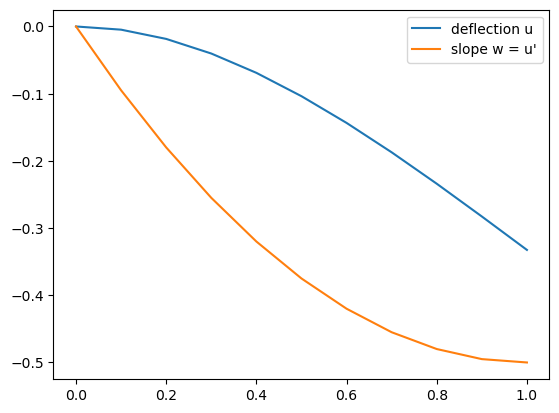

In [3]:
V, ds = beam_setup(1.0, 10)
bcs = [DirichletBC(V.sub(0), Constant(0.0), left),    # u(0) = 0
       DirichletBC(V.sub(1), Constant(0.0), left)]    # u'(0) = w(0) = 0

u, w, p = solve_beam(V, ds, EI=1.0, q=Constant(0.0), P=Constant(-1.0), M=Constant(0.0), bcs=bcs)

print("u(1) = %.4f (exact 1/3)   u'(1) = %.4f (exact 1/2)   p = EI u''' = %.4f (exact -1)"
      % (u(1.0), w(1.0), p(0.5)))

pyplot.figure(dpi=100)
plot(u)
plot(w)
pyplot.autoscale()
pyplot.legend(["deflection u", "slope w = u'"])
pyplot.savefig("beam-0.png")

### 2. Cantilever under its own weight and with an end load

The same solver for the beam that is computed in two dimensions below: length $L = 5$, height $H = 1$, Young's modulus
$E = 1000$, Poisson's ratio $\nu = 0.3$. In plane strain the beam theory uses $E' = E / (1 - \nu^2)$ and
$I = H^3 / 12$, so $EI = E' H^3 / 12$. Two load cases: the own weight $q = -\rho g H$ with $\rho g = 0.3$, and the force
$P = -0.5\, H$ at the free end (the traction $T = (0, -0.5)$ of example 5). The exact tip deflections are
$q L^4 / (8 EI)$ and $P L^3 / (3 EI)$.

own weight: tip deflection -0.2559, beam theory qL^4/(8EI) = -0.2559
end load:   tip deflection -0.2275, beam theory PL^3/(3EI) = -0.2275


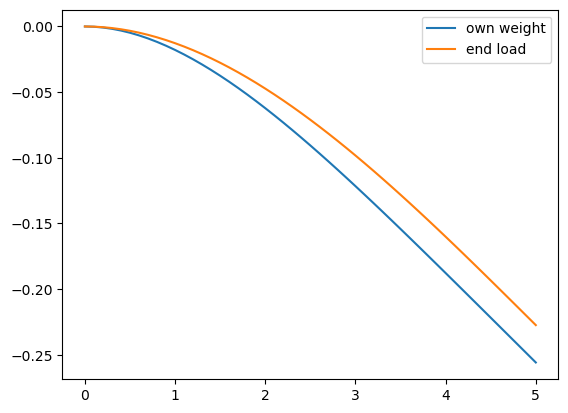

In [4]:
E, nu  = 1000.0, 0.3
length = 5.0
height = 1.0
rho_g  = 0.3
EI     = E/(1 - nu**2) * height**3/12

V, ds = beam_setup(length, 50)
bcs = [DirichletBC(V.sub(0), Constant(0.0), left), DirichletBC(V.sub(1), Constant(0.0), left)]

q = -rho_g*height    # own weight
P = -0.5*height      # end load
u_weight, w, p = solve_beam(V, ds, EI, q=Constant(q), P=Constant(0.0), M=Constant(0.0), bcs=bcs)
u_load,   w, p = solve_beam(V, ds, EI, q=Constant(0.0), P=Constant(P), M=Constant(0.0), bcs=bcs)

print("own weight: tip deflection %.4f, beam theory qL^4/(8EI) = %.4f" % (u_weight(length), q*length**4/(8*EI)))
print("end load:   tip deflection %.4f, beam theory PL^3/(3EI) = %.4f" % (u_load(length), P*length**3/(3*EI)))

pyplot.figure(dpi=100)
plot(u_weight)
plot(u_load)
pyplot.autoscale()
pyplot.legend(["own weight", "end load"])
pyplot.savefig("beam-1.png")

### Linear elasticity in 2D: shared setup

The beam $\Omega = (0, 5) \times (0, 1)$ and the material are those of the 1D beam above. The strain energy density
`psi` is written in terms of $K$ and $G$, the stress is obtained from it by differentiation (`diff`), and `show`
plots the deformed shape together with the strain energy density, which shows where the energy is stored.

In [5]:
nr_elements = 10   # per unit length

mesh = RectangleMesh(Point(0.0, 0.0), Point(length, height),
                     int(length*nr_elements), int(height*nr_elements))
V = VectorFunctionSpace(mesh, 'Lagrange', 1)

# bulk and shear modulus from Young's modulus and Poisson's ratio
K = E/(3*(1 - 2*nu))
G = E/(2*(1 + nu))

def epsilon(u):
    return sym(grad(u))

def psi(eps):
    # strain energy density, volumetric + deviatoric part (3D deviator, plane strain)
    return 0.5*K*tr(eps)**2 + G*(inner(eps, eps) - tr(eps)**2/3)

def sigma(u):
    # stress = derivative of the strain energy with respect to the strain
    eps = variable(epsilon(u))
    return diff(psi(eps), eps)

def right(x, on_boundary):
    return on_boundary and near(x[0], length, tol)

# mark the right end with 1, so that ds(1) integrates over it only
boundaries = MeshFunction('size_t', mesh, mesh.topology().dim() - 1, 0)
AutoSubDomain(right).mark(boundaries, 1)
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

def show(u, filename):
    # deformed configuration (colour: |u|) and the strain energy density (projected to P1 by plot)
    pyplot.figure(figsize=(8, 4.5), dpi=100)
    pyplot.subplot(2, 1, 1)
    c = plot(u, mode='displacement', title='deformed shape, colour = |u|')
    pyplot.colorbar(c, fraction=0.046, pad=0.04)
    pyplot.subplot(2, 1, 2)
    c = plot(psi(epsilon(u)), title='strain energy density')
    pyplot.colorbar(c, fraction=0.046, pad=0.04)
    pyplot.tight_layout()
    pyplot.savefig(filename)

### 3. Dirichlet – Dirichlet

Tension test: the left end is fixed, $u = (0, 0)$, the right end is pulled to $u = (0.25, 0)$; no body force and no
traction, so $\Pi(u) = \int_\Omega \psi(\varepsilon(u)) \; dx$ and the loading enters through the Dirichlet conditions
only. The stored energy is printed; it is the work that was needed to pull the end.

stored strain energy: 6.9473


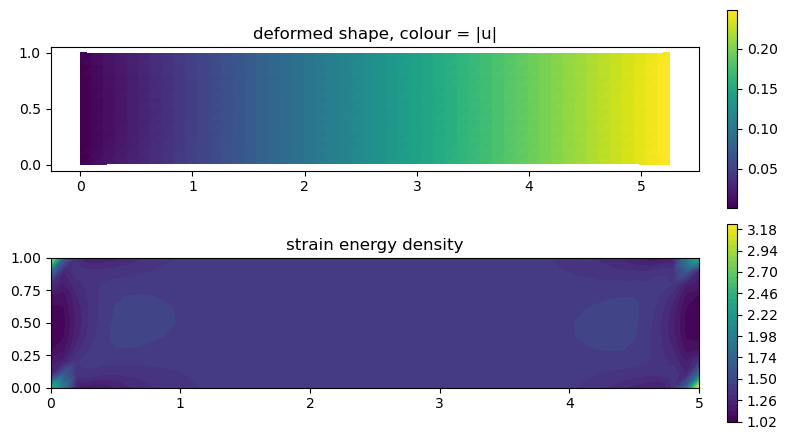

In [6]:
bc0 = DirichletBC(V, Constant((0.0, 0.0)), left)
bc1 = DirichletBC(V, Constant((0.25, 0.0)), right)

u = Function(V)
v = TestFunction(V)

Pi  = psi(epsilon(u)) * dx
dPi = derivative(Pi, u, v)

solve(dPi == 0, u, [bc0, bc1])

print("stored strain energy: %.4f" % assemble(Pi))
show(u, "elasticity-0.png")

### 4. Dirichlet – homogeneous Neumann

Cantilever under its own weight: the left end is clamped, $u = (0, 0)$; body force $f = (0, -\rho g)$ with
$\rho g = 0.3$. Nothing is prescribed on the rest of the boundary, and nothing has to be done about it: the functional
has no boundary term, and the minimization delivers the natural condition $\sigma n = 0$ (traction-free surface) by itself.

Two checks: the tip deflection is compared with the 1D beam of example 2, and $\Pi(u) = -U(u)$ at the minimum,
as derived at the beginning.

tip deflection: 2D -0.2550, 1D beam -0.2559
Pi(u) = -0.0785,  -U(u) = -0.0785


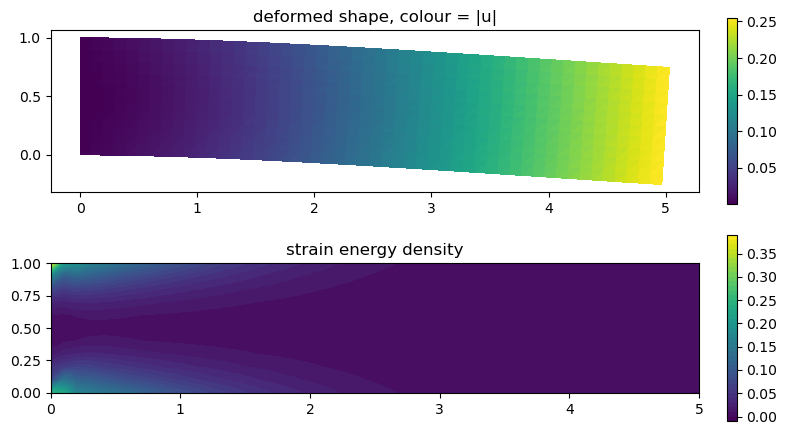

In [7]:
bc = DirichletBC(V, Constant((0.0, 0.0)), left)
f  = Constant((0.0, -rho_g))

u = Function(V)
v = TestFunction(V)

Pi  = ( psi(epsilon(u)) - dot(f, u) ) * dx
dPi = derivative(Pi, u, v)

solve(dPi == 0, u, [bc])

print("tip deflection: 2D %.4f, 1D beam %.4f" % (u(length, height/2)[1], u_weight(length)))
print("Pi(u) = %.4f,  -U(u) = %.4f" % (assemble(Pi), -assemble(psi(epsilon(u))*dx)))
show(u, "elasticity-1.png")

### 5. Dirichlet – Neumann

Cantilever with an end load: the left end is clamped, no body force, and the traction $T = (0, -0.5)$ acts on the
right end $\Gamma$. Its work $\int_\Gamma T \cdot u \; ds$ is the boundary term of the functional; `ds(1)` restricts the
integral to the marked right end. The tip deflection is compared with the 1D beam of example 2 (end load $P = -0.5\, H$).
The small differences between 2D and 1D come from the assumptions of the beam theory (plane cross sections, no shear
deformation) and from the coarse P1 mesh.

tip deflection: 2D -0.2247, 1D beam -0.2275


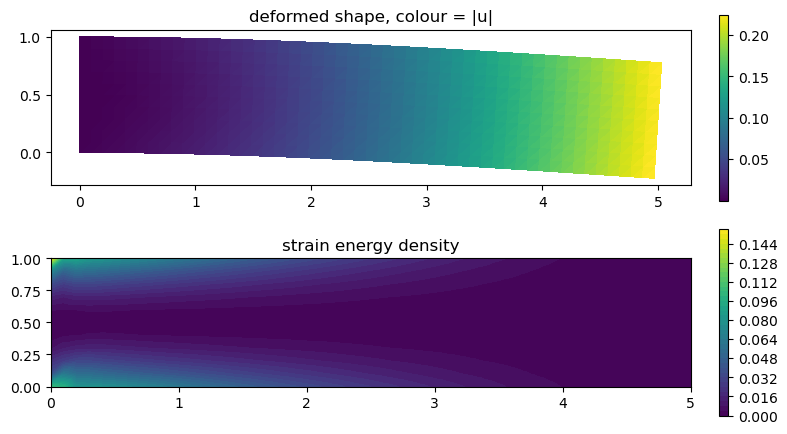

In [8]:
bc = DirichletBC(V, Constant((0.0, 0.0)), left)
T  = Constant((0.0, -0.5))

u = Function(V)
v = TestFunction(V)

Pi  = psi(epsilon(u)) * dx - dot(T, u) * ds(1)
dPi = derivative(Pi, u, v)

solve(dPi == 0, u, [bc])

print("tip deflection: 2D %.4f, 1D beam %.4f" % (u(length, height/2)[1], u_load(length)))
show(u, "elasticity-2.png")

## Exercises

### Exercise 1: The functional of the heat conduction problem

The example of lecture 1: $-\nabla \cdot \nabla u = f$ in $\Omega$, $u$ prescribed on $\partial\Omega \setminus \Gamma$,
outward heat flux $q \cdot n = g$ with $q = -\nabla u$ on $\Gamma$. Consider the functional

$$\Pi(u) = \int_\Omega \tfrac12\, |\nabla u|^2 \; dx - \int_\Omega f\, u \; dx + \int_\Gamma g\, u \; ds .$$

1. Compute the directional derivative $\delta\Pi(u; v)$ and compare with the variational formulation of lecture 1.
2. Integrate by parts and derive the strong form together with the natural boundary condition on $\Gamma$.
   Why does the boundary term of the functional carry a plus sign?
3. Solve problem 3 of lecture 1 ($u(0) = 0$, $f = 0$, $g = -1$ at $x = 1$, 20 elements) in FEniCS as a minimization
   problem with `derivative` and compare with the solution obtained from `a == L`.

### Exercise 2: Simply supported beam

A beam of length $L$ and stiffness $EI$ under the uniform load $q$ rests on supports at both ends: $u(0) = u(L) = 0$,
and the ends are free to rotate.

1. Which boundary conditions are essential, which are natural? What does that mean for the Dirichlet conditions on
   $u$ and on $w = u'$ in the mixed formulation, and what happens at the ends with the bending moment $EI\, u''$?
2. Derive the exact solution of $EI\, u'''' = q$ with these boundary conditions, the deflection at midspan and the
   slope at $x = 0$.
3. Compute the beam with `beam_setup` and `solve_beam` ($EI = 1$, $L = 1$, $q = -1$, 10 and 40 elements) and compare
   the midspan deflection, the slope at $x = 0$ and the multiplier $p$ with the exact solution.

### Exercise 3: Material constants (theory)

1. Show that $\psi = \tfrac12\, K\, (\operatorname{tr}\varepsilon)^2 + G\, \operatorname{dev}\varepsilon : \operatorname{dev}\varepsilon$
   equals $\tfrac12\, \lambda\, (\operatorname{tr}\varepsilon)^2 + \mu\, \varepsilon : \varepsilon$ with $\lambda = K - \tfrac23 G$
   and $\mu = G$, and compute $\sigma = \partial\psi / \partial\varepsilon$ from the second form.
2. Tension test: the stress state is uniaxial, $\sigma = \operatorname{diag}(\sigma_{xx}, 0, 0)$. Show that the strain
   is $\varepsilon = \operatorname{diag}(\varepsilon_{xx}, \varepsilon_{yy}, \varepsilon_{yy})$ with
   $$E = \frac{\sigma_{xx}}{\varepsilon_{xx}} = \frac{\mu\, (3\lambda + 2\mu)}{\lambda + \mu} = \frac{9\, K G}{3K + G}, \qquad
     \nu = -\frac{\varepsilon_{yy}}{\varepsilon_{xx}} = \frac{\lambda}{2\, (\lambda + \mu)} = \frac{3K - 2G}{2\, (3K + G)} .$$
3. Invert the relations to obtain $K$, $G$ and $\lambda$ from $E$ and $\nu$, and check the numbers used above
   ($E = 1000$, $\nu = 0.3$). What happens for $\nu \to \tfrac12$?